<a href="https://colab.research.google.com/github/Fatimalbasha/KAUST-Labs2026/blob/main/Stage3/Day_3/Day3_1_1_Image_Segmentation_Custom_UNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![image.png](https://i.imgur.com/a3uAqnb.png)

# **🐾 Pet Segmentation with U-Net**
In this lab, we will:  
✅ Use the **Oxford-IIIT Pet Dataset** for segmentation  
✅ Build a **custom U-Net model with residual connections**  
✅ Train and evaluate the U-Net model  

The notebook uses the Oxford-IIIT Pet Dataset, which provides:

RGB images of pets

Pixel-wise segmentation masks

## **1️⃣ Dataset Class**

The Oxford-IIIT Pet dataset is preloaded using PyTorch's `OxfordIIITPet` API. We preprocess:
1. **Images**: Normalize and resize  
2. **Targets**: Convert segmentation masks to tensors  

In [ ]:
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn

# Define transforms for images
img_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

# need to subtract 1 from the make to bring it from 1-3 range to 0-2 range (CrossEntropyLoss requires labels to start from 0)
class SubtractOne(nn.Module):
  def forward(self, img):
    return img-1

# Define transforms for masks
target_transforms = transforms.Compose([                    ## Notice how we have a transform for the target (because it is an image)
    transforms.Resize((256, 256)),                          ##        and another one for the image itself.
    transforms.PILToTensor(),
    SubtractOne()                                           ## Question: What do you think would happen if we
                                                            ##  added rotation augmentation to the image only?
])


# Load train and test datasets
train_dataset = OxfordIIITPet(
    root='data/train/', split="trainval", target_types="segmentation", download=True,
    transform=img_transforms, target_transform=target_transforms
)

test_dataset = OxfordIIITPet(
    root='data/test/', split="test", target_types="segmentation", download=True,
    transform=img_transforms, target_transform=target_transforms
)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train Dataset: {len(train_dataset)} images")
print(f"Test Dataset: {len(test_dataset)} images")

100%|██████████| 792M/792M [00:44<00:00, 17.9MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.3MB/s]
100%|██████████| 792M/792M [00:44<00:00, 17.8MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.27MB/s]


Train Dataset: 3680 images
Test Dataset: 3669 images


# **Image transforms**

**Typical image pipeline:**

Resize → make all images same size

Convert to tensor → PyTorch requirement

Normalize → stabilize training



**For masks:**

Converted to tensor

NOT normalized like images

Represent class labels, not pixel intensities



**📌 Exam trap:**

If you normalize masks → ❌ wrong
Masks are labels, not images.

### Let's display some images

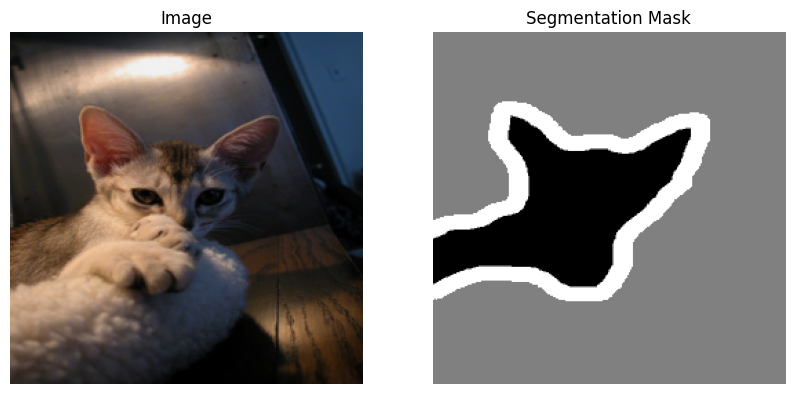

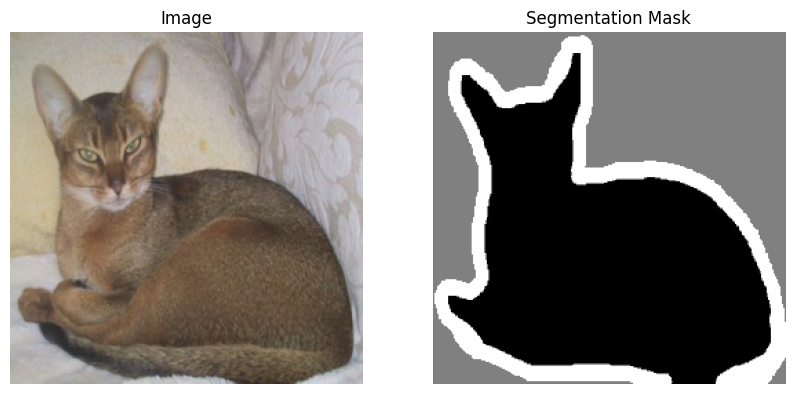

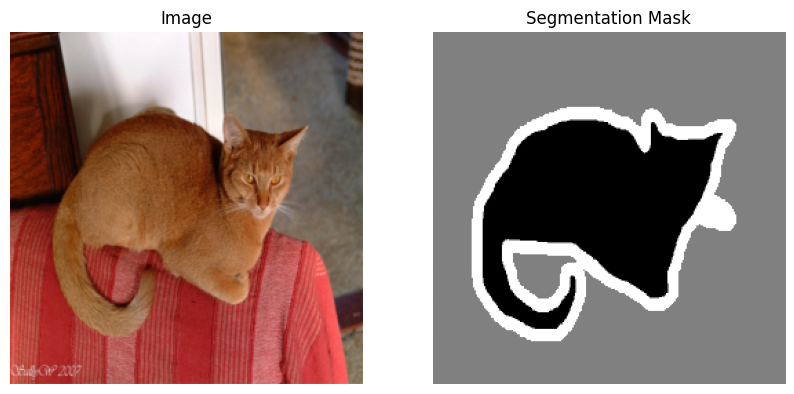

In [ ]:
import matplotlib.pyplot as plt

# Display some images with their masks
for i in range(10,13):
    img, mask = train_dataset[i]
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img.permute(1, 2, 0))  # Convert (C, H, W) to (H, W, C)
    axes[0].set_title("Image")
    axes[0].axis("off")
    axes[1].imshow(mask.squeeze(), cmap="gray")
    axes[1].set_title("Segmentation Mask")
    axes[1].axis("off")
    plt.show()


## **2️⃣ Model Class**

#### We define a **U-Net** model with skip connections (residuals) implemented using **concatenation**.


U-Net has:

Encoder → captures what is in the image

Decoder → recovers where it is

Skip connections → keep spatial details

In [ ]:
import torch
import torch.nn as nn

class UNet(nn.Module):
    """U-Net model with skip connections (Residuals)."""
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()

        # --- ENCODER ---
        # Learn high-level semantic features (pet vs background)
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        # --- BOTTLENECK ---
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True)
        )

        # --- DECODER ---
        # Restore pixel-level precision
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = nn.Sequential(
            nn.Conv2d(1024, 512, kernel_size=3, padding=1),  # 512 + 512 (residual) = 1024 input channels
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),  # 256 + 256 (residual) = 512 input channels
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),  # 128 + 128 (residual) = 256 input channels
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),  # 64 + 64 (residual) = 128 input channels
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        # Final layer
        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

        # Pooling
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        # --- ENCODER ---
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2))
        enc4 = self.enc4(self.pool(enc3))

        # --- BOTTLENECK ---
        bottleneck = self.bottleneck(self.pool(enc4))

        # --- DECODER + SKIP CONNECTIONS ---
        x = self.up4(bottleneck)
        x = torch.cat([x, enc4], dim=1)
        dec4 = self.dec4(x)

        x = self.up3(dec4)
        x = torch.cat([x, enc3], dim=1)
        dec3 = self.dec3(x)

        x = self.up2(dec3)
        x = torch.cat([x, enc2], dim=1)
        dec2 = self.dec2(x)

        x = self.up1(dec2)
        x = torch.cat([x, enc1], dim=1)
        dec1 = self.dec1(x)

        # --- FINAL LAYER ---
        return self.final(dec1)


## **3️⃣ Training and Validation Loops**

To train the U-Net model, we use **Binary Cross Entropy (BCE) Loss**.


In [ ]:
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm

# 🔹 Training Loop
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for images, masks in tqdm(dataloader):
        images, masks = images.to(device), masks.to(device).squeeze(dim=1).to(torch.long)  # mask shape becomes [N, H, W]

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

# 🔹 Validation Loop
def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device).squeeze(dim=1).to(torch.long)    # mask shape becomes [N, H, W]

            outputs = model(images)  # Now [N, H, W]
            loss = criterion(outputs, masks)
            total_loss += loss.item()

    return total_loss / len(dataloader)

## **4️⃣ Running Training**

In [ ]:
import torch

# Initialize model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = UNet(in_channels=3, out_channels=3).to(device)  # Output channels = 3 classes

## **🔹 Why `out_channels=3` in U-Net?**
Our segmentation model needs to **predict probabilities** for each pixel belonging to **one of 3 classes** (background, pet, and boundary).  

✅ Instead of predicting a **single-channel mask**, we predict **3 channels**, where:  
- **Channel 0** → Probability of **background**  
- **Channel 1** → Probability of **pet**  
- **Channel 2** → Probability of **boundary**  

🚀 **How does it work?**
- The output of U-Net is a **(batch_size, 3, height, width)** tensor.
- We use `CrossEntropyLoss`, which expects a **multi-class probability map**.
- The **target masks** should be in **label-encoded format** (`(batch_size, height, width)` with values `0, 1, 2` for each pixel).
- In inference, we could take `argmax(dim=1)`, which picks the class with the highest probability for each pixel.



In [ ]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
# if Binary segmentation ---> out_channels=1, BCEWithLogitsLoss
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

num_epochs = 10  # Define number of epochs
train_losses = []
val_losses = []

# Training Loop
for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")


100%|██████████| 115/115 [1:33:25<00:00, 48.75s/it]


Epoch 1/10: Train Loss = 0.7797, Val Loss = 0.6170


 54%|█████▍    | 62/115 [54:23<43:53, 49.69s/it]

### Plot loss

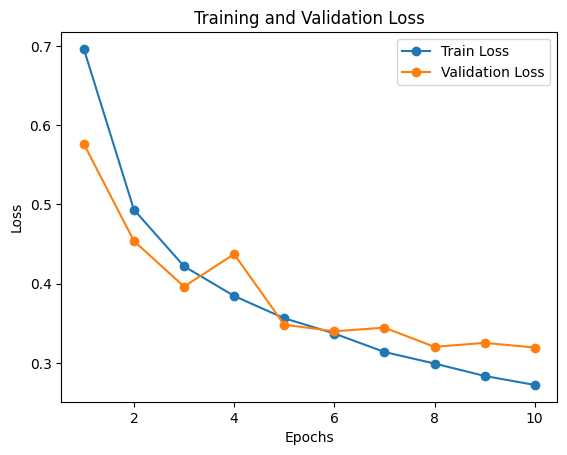

In [ ]:
### **🔹 Plot Training Loss Curve**
import matplotlib.pyplot as plt

plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

**Typical interpretation:**

Train ↓, Val ↓ → good

Train ↓, Val ↑ → overfitting

Both high → underfitting

## **5️⃣ Visualizing Predictions**

To evaluate the model, we compare the predicted segmentation masks with the ground truth masks.


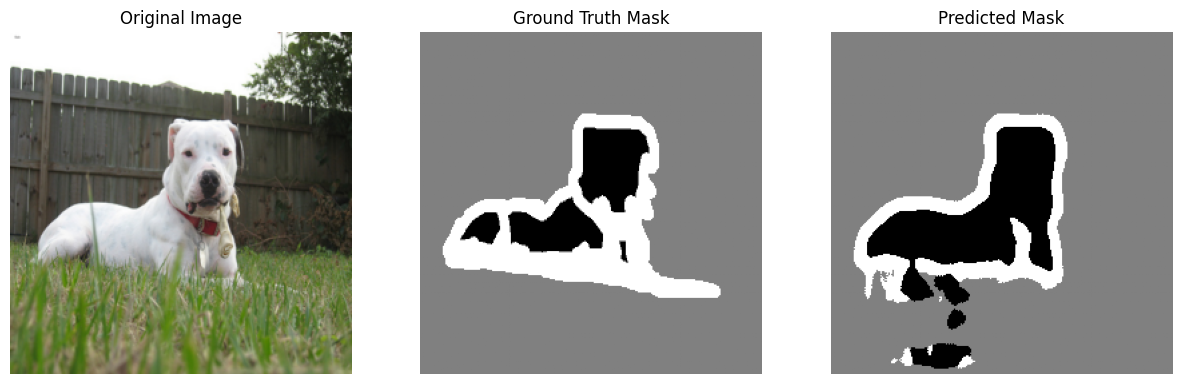

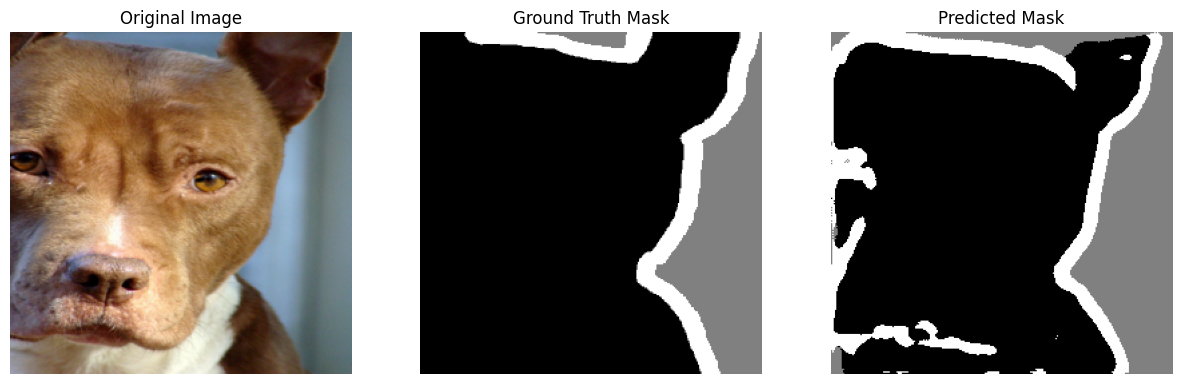

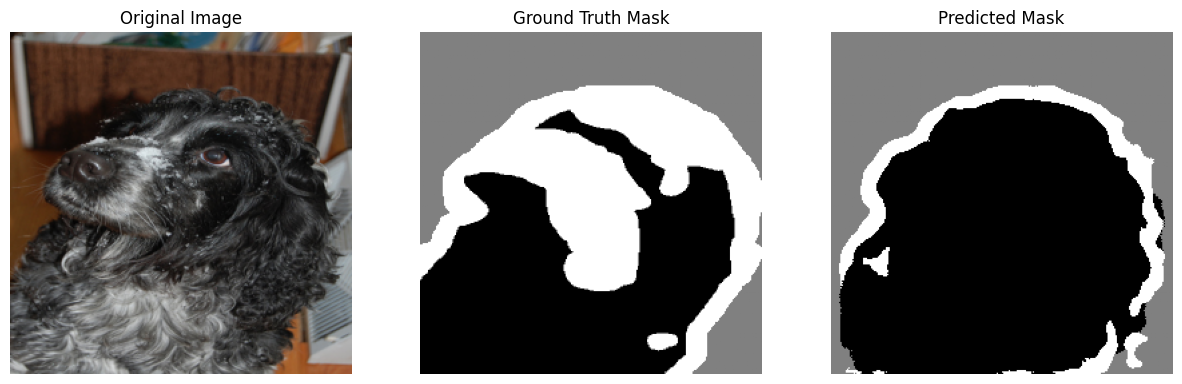

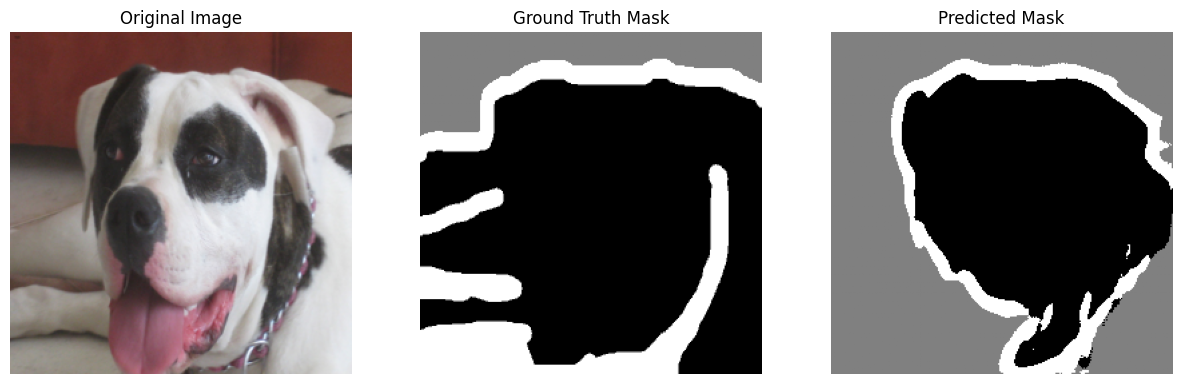

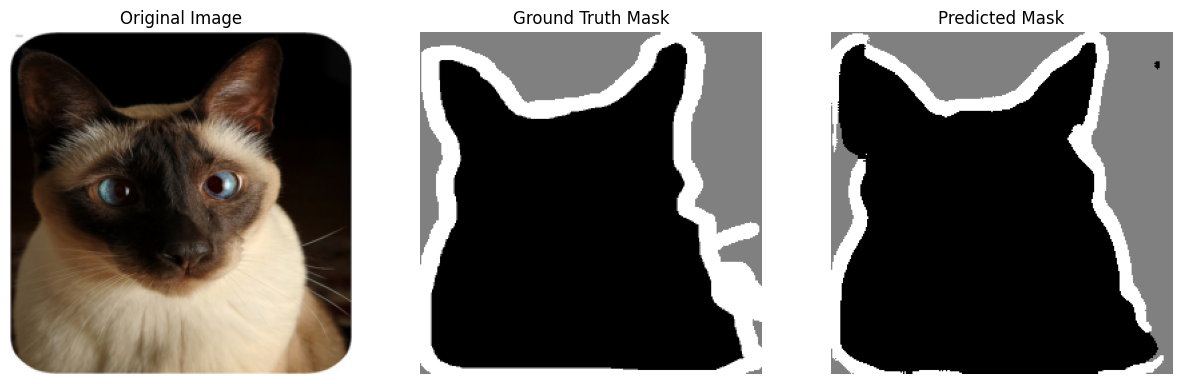

In [ ]:
import random
import matplotlib.pyplot as plt

model.eval()
# Get some test samples
test_samples = random.sample(range(len(test_dataset)), 5)

for idx in test_samples:
    img, mask = test_dataset[idx]

    with torch.no_grad():
        pred_mask = model(img.unsqueeze(0).to(device))  # Forward pass

    pred_mask = torch.softmax(pred_mask, dim=1)  # Convert logits to probabilities
    pred_mask = pred_mask.argmax(dim=1).cpu().squeeze().numpy()  # Get class with highest probability

    # Display images
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0))
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(mask.squeeze(), cmap="gray")
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis("off")

    axes[2].imshow(pred_mask, cmap="gray")  # Show class map
    axes[2].set_title("Predicted Mask")
    axes[2].axis("off")

    plt.show()


### Contributed by: Mohamed Eltayeb

# Extra from me

# **2) Compute IoU (Jaccard) metric**
# **Multi-class IoU (mean IoU)**

In [ ]:
import torch

def mean_iou(pred, target, num_classes, ignore_index=None, eps=1e-7):
    """
    pred:   (B, H, W)  predicted class indices
    target: (B, H, W)  ground truth class indices
    """
    ious = []
    for c in range(num_classes):
        if ignore_index is not None and c == ignore_index:
            continue

        pred_c = (pred == c)
        targ_c = (target == c)

        intersection = (pred_c & targ_c).sum().float()
        union = (pred_c | targ_c).sum().float()
        if union == 0:
            continue  # skip if class not present
        ious.append((intersection + eps) / (union + eps))

    return torch.stack(ious).mean() if len(ious) > 0 else torch.tensor(0.0)


**Use it during validation**

In [ ]:
# model.eval()
# total_iou = 0.0
# n_batches = 0

# with torch.no_grad():
#     for images, masks in val_loader:
#         images, masks = images.to(device), masks.to(device)

#         logits = model(images)              # (B, C, H, W)
#         pred = torch.argmax(logits, dim=1)  # (B, H, W)

#         batch_iou = mean_iou(pred, masks, num_classes=3)
#         total_iou += batch_iou.item()
#         n_batches += 1

# val_miou = total_iou / max(n_batches, 1)
# print("Val mIoU:", val_miou)


# **3) Compute Dice score (F1 for segmentation)**
# **Multi-class Dice (mean Dice)**

In [ ]:
def mean_dice(pred, target, num_classes, ignore_index=None, eps=1e-7):
    dices = []
    for c in range(num_classes):
        if ignore_index is not None and c == ignore_index:
            continue

        pred_c = (pred == c)
        targ_c = (target == c)

        intersection = (pred_c & targ_c).sum().float()
        denom = pred_c.sum().float() + targ_c.sum().float()
        if denom == 0:
            continue
        dices.append((2 * intersection + eps) / (denom + eps))

    return torch.stack(dices).mean() if len(dices) > 0 else torch.tensor(0.0)


**Use it during validation**

In [ ]:
model.eval()
total_dice = 0.0
n_batches = 0

with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        pred = torch.argmax(logits, dim=1)

        batch_dice = mean_dice(pred, masks, num_classes=3)
        total_dice += batch_dice.item()
        n_batches += 1

val_mdice = total_dice / max(n_batches, 1)
print("Val mean Dice:", val_mdice)


# **To output more images**

In [ ]:
for i in range(30):
    img, mask = dataset[i]
    show_image(img, mask)


# Case 2: Images are shown from a DataLoader (very common)

In [ ]:
images, masks = next(iter(val_loader))

for i in range(5):
    plt.imshow(images[i].permute(1, 2, 0))
    plt.show()


# **Case 3: Batch size is SMALL (this is the tricky exam case)**

In [ ]:
shown = 0

for images, masks in val_loader:
    for i in range(images.size(0)):
        plt.imshow(images[i].permute(1, 2, 0))
        plt.show()

        shown += 1
        if shown == 30:
            break
    if shown == 30:
        break


# **Case 4: Showing image + ground truth + prediction (segmentation)**

In [ ]:
for i in range(30):
    image = images[i]
    gt = masks[i]
    pred = preds[i]

    plot_triplet(image, gt, pred)
